In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_excel("ventas_limpio.xlsx")

df["total_venta"] = df["Cantidad"] * df["Precio"]

def clasificar(total):
    if total < 200:
        return "baja"
    elif total < 600:
        return "media"
    else:
        return "alta"

df["nivel_venta"] = df["total_venta"].apply(clasificar)

X = df[["Producto", "Categoria", "Cantidad", "Precio", "Tienda", "Ciudad"]]
y = df["nivel_venta"]

X = X.apply(LabelEncoder().fit_transform)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("\nReporte completo:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Reporte completo:
               precision    recall  f1-score   support

        alta       1.00      1.00      1.00     11285
        baja       1.00      1.00      1.00       319
       media       1.00      1.00      1.00      3325

    accuracy                           1.00     14929
   macro avg       1.00      1.00      1.00     14929
weighted avg       1.00      1.00      1.00     14929



In [23]:
df.dtypes


,0
ID_Venta,int64
Producto,object
Categoria,object
Cliente,object
Fecha,datetime64[ns]
Cantidad,int64
Precio,int64
Tienda,object
Ciudad,object


In [25]:
X_pred = pd.get_dummies(df[['Producto','Categoria','Tienda','Ciudad','Cliente']])

In [26]:
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)


In [27]:
df['nivel_venta_predicho'] = modelo_arbol.predict(X_pred)


In [28]:
# Guardar en CSV
df.to_csv('ventas_limpio_con_predicciones.csv', index=False)


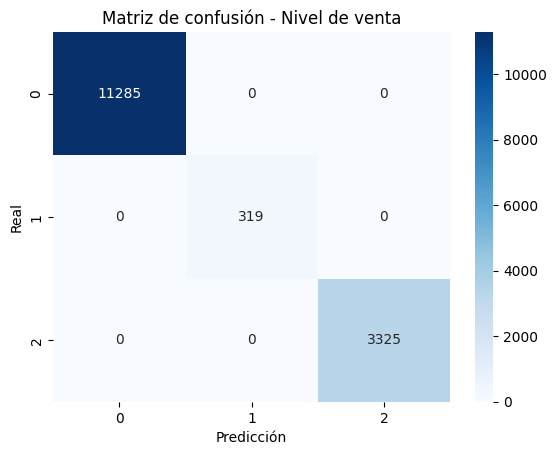

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - Nivel de venta')
plt.show()


In [9]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

# Calcular métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest - Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1:", f1_rf)


Random Forest - Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)

y_pred_arbol = modelo_arbol.predict(X_test)

accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol, average='weighted')
recall_arbol = recall_score(y_test, y_pred_arbol, average='weighted')
f1_arbol = f1_score(y_test, y_pred_arbol, average='weighted')

print("Árbol de Decisión - Accuracy:", accuracy_arbol)
print("Precision:", precision_arbol)
print("Recall:", recall_arbol)
print("F1-Score:", f1_arbol)


Árbol de Decisión - Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


In [11]:
modelo_arbol_opt = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol_opt.fit(X_train, y_train)
y_pred_arbol_opt = modelo_arbol_opt.predict(X_test)

from sklearn.ensemble import RandomForestClassifier
modelo_rf_opt = RandomForestClassifier(n_estimators=150, random_state=42)
modelo_rf_opt.fit(X_train, y_train)
y_pred_rf_opt = modelo_rf_opt.predict(X_test)


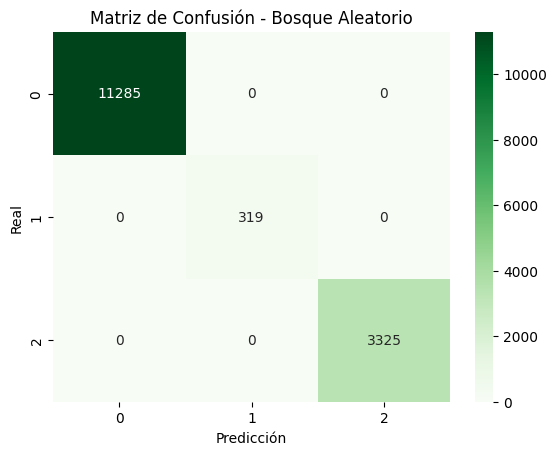

In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Bosque Aleatorio')
plt.show()


In [13]:
import pandas as pd

# Carga el Excel
df = pd.read_excel('ventas_limpio.xlsx')


In [17]:
# Variables de entrada
X = df[['Producto', 'Categoria', 'Cliente', 'Fecha', 'Cantidad', 'Precio', 'Tienda', 'Ciudad']]  # ajusta según tu código
# Si tu modelo necesita codificación, asegúrate de aplicarla igual que en tu entrenamiento

In [19]:
X_pred = df[['Producto', 'Categoria', 'Cantidad', 'Precio', 'Tienda', 'Ciudad']]
